In [1]:
'''if 'google.colab' in str(get_ipython()):
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install .'''

"if 'google.colab' in str(get_ipython()):\n    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy\n    from os import chdir as cd\n    cd('/content/OptiCommPy/')\n    ! pip install ."

In [2]:
from tqdm.notebook import tqdm
import numpy as np
from numpy.lib.stride_tricks import as_strided
from numpy.fft import fft, ifft, fftfreq
from  scipy.constants import c
import matplotlib.pyplot as plt
import time

from optic.comm.modulation import modulateGray, grayMapping
from optic.dsp.core import pnorm, upsample, firFilter, pulseShape, signalPower, phaseNoise, decimate, symbolSync, finddelay
from optic.dsp.equalization import edc, mimoAdaptEqualizer
from optic.models.devices import iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel, mzm, edfa
from optic.models.channels import linearFiberChannel, awgn
from optic.utils import parameters
from optic.comm.metrics import fastBERcalc
from optic.plot import pconst, eyediagram, plotPSD
from optic.models.tx import simpleWDMTx, pamTransmitter
from optic.dsp.carrierRecovery import cpr

## Equalização
---

## Sumário
---

- [Equalizador MIMO 2 x 2](#equalizador-MIMO-2-x-2)


### Equalizador MIMO 2 x 2

Em sistemas coerentes modernos, dois sinais independentes são transmitidos simultaneamente em duas polarizações ortogonais (X e Y, ou V e H), dobrando a taxa de dados sem aumento de largura de banda — isso é PDM (Polarization-Division Multiplexing).

No entanto, devido à dispersão de modo de polarização (PMD), as polarizações se misturam durante a propagação na fibra. Quando o sinal chega no receptor, não está mais separado como foi transmitido.



<center><img src = "https://github.com/silasabs/CoherentOptics/blob/main/figures/mimo%20butterfly%20equalizer.png?raw=True"/></center>
<center>GitHub Silas João</center>

O equalizador MIMO 2×2 reconstrói os sinais transmitidos separando corretamente os dois fluxos de dados da mistura recebida, usando quatro filtros FIR adaptativos:

$$\begin{bmatrix}
y1[k] \\ y2[k]
\end{bmatrix} =
\begin{bmatrix}
W_{1V}[n] & W_{1H}[n] \\
W_{2V}[n] & W_{2H}[n]
\end{bmatrix} .
\begin{bmatrix}
X_V[k] \\ X_H[k]
\end{bmatrix}$$

  - $X_V[k]:$ entrada da polarização vertical
  - $X_H[k]:$ entrada da polarização horizontal
  - $y_1[k],y_2[k]:$ sinais equalizados que idealmente correspondem aos sinais transmitidos

Esse modelo é chamado de "butterfly equalizer" pela forma de cruzamento dos filtros na arquitetura.

O uso do equalizador MIMO 2x2 (butterfly) é imprescindível em sistemas coerentes com multiplexação por polarização, pois ele permite separar sinais misturados pela fibra (PMD), restaurar as constelações originais e viabilizar altas taxas de transmissão. É um dos principais blocos que você deve dominar para avançar seu projeto de compensação de PMD com equalizadores adaptativos.

In [3]:
def create_windows(x, paramEq):
    """
    Cria janelas temporais para polarização X e Y (coluna 0 e coluna 1), organizadas do tap mais antigo → tap mais novo.
    Essas matrizes são usadas posteriormente pelo equalizador adaptativo.

    Parametros
    ----------
    x : np.ndarray - Sinal recebido, no formato [N_amostras x 2], onde a coluna 0 = polarização X, coluna 1 = polarização Y.
    paramEq : parameters - Estrutura de parâmetros que contém o número de taps (paramEq.nTaps).

    Retorno
    -------
      - xV (np.ndarray): matriz [N x nTaps] com janelas temporais da polarização X (coluna 0).
      - xH (np.ndarray): matriz [N x nTaps] com janelas temporais da polarização Y (coluna 1).
    """

    N = x.shape[0] - paramEq.nTaps + 1
    shape = (N, paramEq.nTaps)
    x0 = np.ascontiguousarray(x[:, 0])                                          # Colocando x[:, 0] como sinal contíguos
    x1 = np.ascontiguousarray(x[:, 1])                                          # Colocando x[:, 1] como sinal contíguos

    stridesx = x0.itemsize
    xV_ = as_strided(x0, shape=shape, strides=(stridesx,stridesx))
    xV = xV_[:, ::-1]                                                           # Polarização X é a coluna 0

    stridesy = x1.itemsize
    xH_ = as_strided(x1, shape=shape, strides=(stridesy,stridesy))
    xH = xH_[:, ::-1]                                                           # Polarização Y é a coluna 1

    return xV, xH

In [4]:
def ddlmsUp(x, constSymb, nModes, paramEq):
    """
    Equalizador DD-LMS para um sistema MIMO 2x2.
    Implementação amostra-por-amostra com lógica de atualização corrigida.
    Parameters
    ----------
      x : np.array - Sinal de entrada após o canal (polarizações X e Y nas colunas 0 e 1).
      constSymb : np.array - Conjunto de símbolos da constelação (ex: QPSK, 16QAM) para decisões bruscas.
      nModes : int - Número de modos/polarizações (tipicamente 2).
      paramEq : parameters - Estrutura contendo parâmetros do equalizador, incluindo:
        - nTaps : número de coeficientes do filtro FIR por ramo.
        - mu : passo de atualização do LMS.
        - progBar : habilita/desabilita barra de progresso.

    Returns
    -------
      - y (np.array, shape = [N, nModes]): saída estimada do equalizador para cada modo.
      - e (np.array, shape = [N, nModes]): erro de decisão (diferença entre símbolo decidido e saída).
      - w (np.array, shape = [nTaps, nModes**2]): matriz de coeficientes do equalizador MIMO 2x2.
      Cada coluna corresponde a um dos quatro ramos do equalizador:
            w[:,0] → w_xx  (entrada X → saída X)
            w[:,1] → w_xy  (entrada Y → saída X)
            w[:,2] → w_yx  (entrada X → saída Y)
            w[:,3] → w_yy  (entrada Y → saída Y)
            
    Referências
    -----------
    [1] Digital Coherent Optical Systems, Architecture and Algorithms
    """

    # Parâmetros para o processamento em blocos
    blockSize = 2**11
    N = x.shape[0] - paramEq.nTaps + 1
    nBlocks = N // blockSize

    if N <= 0:
      raise ValueError("Sinal curto demais para nTaps")

    # Obtém o atraso da filtragem FIR
    delay = (paramEq.nTaps - 1) // 2

    # --- Pré-alocação de Memória ---
    y = np.zeros((len(x), nModes), dtype='complex')
    e = np.zeros((len(x), nModes), dtype='complex')
    w = np.zeros((paramEq.nTaps, nModes**2), dtype='complex')

    # single spike initialization
    w[delay, 0] = 1                                                             # Filtro principal w_xx (para o Mode 0)
    w[delay, 3] = 1                                                             # Filtro principal w_yy (para o Mode 1)

    for i in tqdm(range(nBlocks), disable=not(paramEq.progBar)):

        n = i * blockSize
        n_delay = delay + n + blockSize
        x_ = x[n : n + blockSize + paramEq.nTaps - 1, :]

        # cria janelas temporais para polarização X e Y (coluna 0 e coluna 1)
        xV, xH = create_windows(x_, paramEq)

        # calcula a saída do equalizador 2x2
        y[delay + n : n_delay, 0] = xV @ w[:, 0] + xH @ w[:, 1]
        y[delay + n : n_delay, 1] = xV @ w[:, 2] + xH @ w[:, 3]

        y0 = y[delay + n : n_delay, 0]
        y1 = y[delay + n : n_delay, 1]

        # decisão brusca
        d0 = constSymb[np.argmin(np.abs(y0[:, None] - constSymb), axis = 1)]
        d1 = constSymb[np.argmin(np.abs(y1[:, None] - constSymb), axis = 1)]

        e[delay + n : n_delay, 0] = d0 - y[delay + n : n_delay, 0]
        e[delay + n : n_delay, 1] = d1 - y[delay + n : n_delay, 1]

        # atualiza os coeficientes do filtro
        w[:,0] += paramEq.mu[1] * (xV.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xx = w[:, 0]
        w[:,2] += paramEq.mu[1] * (xV.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yx = w[:, 2]
        w[:,1] += paramEq.mu[1] * (xH.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xy = w[:, 1]
        w[:,3] += paramEq.mu[1] * (xH.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yy = w[:, 3]

    return y, e, w

In [5]:
def rdeUp(x, constSymb, nModes, paramEq, y=None, e=None, w=None, preConv=False):
    """
    Equalizador RDE (Radius-Directed Equalization) para um sistema MIMO 2x2.
    Implementação em blocos com lógica de atualização corrigida.

    Parameters
    ----------
    x : np.array - Sinal de entrada após o canal (polarizações X e Y nas colunas 0 e 1).
    constSymb : np.array - Conjunto de símbolos da constelação (ex: 16QAM) para obter os raios ideais.
    nModes : int - Número de modos/polarizações (tipicamente 2).
    paramEq : parameters - Estrutura contendo parâmetros do equalizador, incluindo:
        - nTaps : número de coeficientes do filtro FIR por ramo.
        - mu : passo de atualização do RDE.
        - N1 : iteração para o "kick" de ortogonalidade.
        - progBar : habilita/desabilita barra de progresso.
    y : np.array, opcional - Array de saída pré-alocado (usado no modo preConv).
    e : np.array, opcional - Array de erro pré-alocado (usado no modo preConv).
    w : np.array, opcional - Matriz de pesos pré-convergidos do CMA (usado no modo preConv).
    preConv : bool, opcional - Flag que indica se a função está sendo chamada após uma pré-convergência CMA.

    Returns
    -------
      - y (np.array, shape = [N, nModes]): saída estimada do equalizador para cada modo.
      - e (np.array, shape = [N, nModes]): erro de decisão (diferença entre símbolo decidido e saída).
      - w (np.array, shape = [nTaps, nModes**2]): matriz de coeficientes do equalizador MIMO 2x2.
      Cada coluna corresponde a um dos quatro ramos do equalizador:
            w[:,0] → w_xx  (entrada X → saída X)
            w[:,1] → w_xy  (entrada Y → saída X)
            w[:,2] → w_yx  (entrada X → saída Y)
            w[:,3] → w_yy  (entrada Y → saída Y)

    Referências
    -----------
    [1] Digital Coherent Optical Systems, Architecture and Algorithms
    """

    # Parâmetros para o processamento em blocos
    blockSize = 2**11
    N = x.shape[0] - paramEq.nTaps + 1
    nBlocks = N // blockSize

    # Obtém o atraso da filtragem FIR
    delay = (paramEq.nTaps - 1) // 2

    # obtem os raios da constelação M-QAM
    Rrde = np.unique(np.abs(constSymb))

    if preConv == False:

        paramEq.N2 = 0

        y = np.zeros((len(x), nModes), dtype='complex')
        e = np.zeros((len(x), nModes), dtype='complex')
        w = np.zeros((paramEq.nTaps, nModes**2), dtype='complex')

        # single spike initialization
        w[delay, 0] = 1                                                             # Filtro principal w_xx (para o Mode 0)
        w[delay, 3] = 1                                                             # Filtro principal w_yy (para o Mode 1)

    N1_block = paramEq.N1 // blockSize if paramEq.N1 > 0 else -1

    for i in tqdm(range(nBlocks), disable=not(paramEq.progBar)):

        n = i * blockSize
        n_delay = delay + n + blockSize
        x_ = x[n : n + blockSize + paramEq.nTaps - 1, :]

        # cria janelas temporais para polarização X e Y (coluna 0 e coluna 1)
        xV, xH = create_windows(x_, paramEq)

        # calcula a saída do equalizador 2x2
        y[delay + n : n_delay, 0] = xV @ w[:, 0] + xH @ w[:, 1]
        y[delay + n : n_delay, 1] = xV @ w[:, 2] + xH @ w[:, 3]

        y0 = np.abs(y[delay + n : n_delay, 0])
        y1 = np.abs(y[delay + n : n_delay, 1])

        R1 = np.argmin(np.abs(Rrde - y0[:, None]), axis = 1)
        R2 = np.argmin(np.abs(Rrde - y1[:, None]), axis = 1)

        # calcula e atualiza erro para cada modo de polarização
        e[delay + n : n_delay, 0] = y[delay + n : n_delay, 0] * (Rrde[R1]**2 - y0**2)
        e[delay + n : n_delay, 1] = y[delay + n : n_delay, 1] * (Rrde[R2]**2 - y1**2)

        # atualiza os coeficientes do filtro
        w[:,0] += paramEq.mu[0] * (xV.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xx = w[:, 0]
        w[:,2] += paramEq.mu[0] * (xV.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yx = w[:, 2]
        w[:,1] += paramEq.mu[0] * (xH.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xy = w[:, 1]
        w[:,3] += paramEq.mu[0] * (xH.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yy = w[:, 3]

        if i == N1_block:
            # Defina a polarização Y como ortogonal a X para evitar
            # a convergência para a mesma polarização (evitar a singularidade CMA)
            w[:,3] =  np.conj(w[:,0][::-1])
            w[:,2] = -np.conj(w[:,1][::-1])

    return y, e, w

In [6]:
def cmaUp(x, constSymb, nModes, paramEq, preConv=False):
    """
    Equalizador CMA (Constant-Modulus Algorithm) para um sistema MIMO 2x2.

    Esta função implementa o algoritmo CMA usando uma abordagem de
    processamento em blocos para alta performance em GPU. Ela é projetada
    para realizar a convergência cega inicial, separando as polarizações
    e compensando o deslocamento de frequência.

    Parameters
    ----------
    x : np.array - Sinal de entrada após o canal (polarizações X e Y nas colunas 0 e 1).
    constSymb : np.array - Conjunto de símbolos da constelação (ex: 16QAM) para obter os raios ideais.
    nModes : int - Número de modos/polarizações (tipicamente 2).
    paramEq : parameters - Estrutura contendo parâmetros do equalizador, incluindo:
        - nTaps : número de coeficientes do filtro FIR por ramo.
        - mu : passo de atualização do RDE.
        - N1 : iteração para aplicar o "kick" de ortogonalidade.
        - N2 : iteração para parar a fase de pré-convergência do CMA.
        - progBar : booleano para habilitar/desabilitar a barra de progresso.
    preConv : bool, opcional - Flag que ativa o modo de pré-convergência. Se True, o loop para na iteração N2. O padrão é False.

    Returns
    -------
      - y (np.array, shape = [N, nModes]): saída estimada do equalizador para cada modo.
      - e (np.array, shape = [N, nModes]): erro de decisão (diferença entre símbolo decidido e saída).
      - w (np.array, shape = [nTaps, nModes**2]): matriz de coeficientes do equalizador MIMO 2x2.
      Cada coluna corresponde a um dos quatro ramos do equalizador:
            w[:,0] → w_xx  (entrada X → saída X)
            w[:,1] → w_xy  (entrada Y → saída X)
            w[:,2] → w_yx  (entrada X → saída Y)
            w[:,3] → w_yy  (entrada Y → saída Y)

    Referências
    -----------
    [1] Digital Coherent Optical Systems, Architecture and Algorithms
    """

    # Parâmetros para o processamento em blocos
    blockSize = 2**11
    N = x.shape[0] - paramEq.nTaps + 1
    blocks_default = N // blockSize

    if N <= 0:
      raise ValueError("Sinal curto demais para nTaps")

    # Obtém o atraso da filtragem FIR
    delay = (paramEq.nTaps - 1) // 2

    y = np.zeros((len(x), nModes),  dtype='complex')
    e = np.zeros((len(x), nModes),  dtype='complex')
    w = np.zeros((paramEq.nTaps, nModes**2),  dtype='complex')

    # single spike initialization
    w[delay, 0] = 1                                                             # Filtro principal w_xx (para o Mode 0)
    w[delay, 3] = 1                                                             # Filtro principal w_yy (para o Mode 1)

    # constante relacionada às características da modulação para o algoritmo CMA
    R = np.mean(np.abs(constSymb)**4) / np.mean(np.abs(constSymb)**2)

    N1_block = paramEq.N1 // blockSize if paramEq.N1 > 0 else -1
    nBlocks = paramEq.N2 // blockSize if preConv else blocks_default

    for i in tqdm(range(nBlocks), disable=not(paramEq.progBar)):

        n = i * blockSize
        n_delay = delay + n + blockSize
        x_ = x[n : n + blockSize + paramEq.nTaps - 1, :]

        # cria janelas temporais para polarização X e Y (coluna 0 e coluna 1)
        xV, xH = create_windows(x_, paramEq)

        # calcula a saída do equalizador 2x2
        y[delay + n : n_delay, 0] = xV @ w[:, 0] + xH @ w[:, 1]
        y[delay + n : n_delay, 1] = xV @ w[:, 2] + xH @ w[:, 3]

        # calcula e atualiza erro para cada modo de polarização
        e[delay + n : n_delay, 0] = y[delay + n : n_delay, 0] * (R - np.abs(y[delay + n : n_delay, 0])**2)
        e[delay + n : n_delay, 1] = y[delay + n : n_delay, 1] * (R - np.abs(y[delay + n : n_delay, 1])**2)

        # atualiza os coeficientes do filtro
        w[:,0] += paramEq.mu[0] * (xV.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xx = w[:, 0]
        w[:,2] += paramEq.mu[0] * (xV.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yx = w[:, 2]
        w[:,1] += paramEq.mu[0] * (xH.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xy = w[:, 1]
        w[:,3] += paramEq.mu[0] * (xH.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yy = w[:, 3]

        # Ortogonalização CMA apenas uma vez quando N1 for atingido
        if i == N1_block:
            w[:,3] =  np.conj(w[:,0][::-1])
            w[:,2] = -np.conj(w[:,1][::-1])

    if preConv:
        w_ = np.max(np.abs(w))
        w = w/w_ if w_ > 1e-6 else w
        y, e, w = rdeUp(x, constSymb, nModes, paramEq, y, e, w, preConv=True)

    return y, e, w

In [7]:
def mimoAdaptEq(x, paramEq):
    """
    Equalizador adaptativo MIMO 2x2

    Returns
    -------
    tuple
        - y (np.array): estimativa dos símbolos.
        - e (np.array): erro associado a cada modo de polarização.
        - w (np.array): matriz de coeficientes.

    Raises
    ------
    ValueError
        Caso o sinal não possua duas polarizações.

    ValueError
        Caso o algoritmo seja especificado incorretamente.
    """

    if x.shape[1] != 2:
        raise ValueError("O sinal deve conter duas polarizações")

    nModes = x.shape[1]

    # obtem os símbolos da constelação
    constSymb = grayMapping(paramEq.M, paramEq.constType)
    # normaliza os símbolos da constelação
    constSymb = pnorm(constSymb)

    if paramEq.alg == 'cma':
        y, e, w = cmaUp(x, constSymb, nModes, paramEq)
    elif paramEq.alg == 'rde':
        y, e, w = rdeUp(x, constSymb, nModes, paramEq)
    elif paramEq.alg == 'cma-to-rde':
        y, e, w = cmaUp(x, constSymb, nModes, paramEq, preConv=True)
    elif paramEq.alg == 'dd-lms':
        y, e, w = ddlmsUp(x, constSymb, nModes, paramEq)
    else:
        raise ValueError("Algoritmo de equalização especificado incorretamente.")

    return y, e, w

### Simulação WDM 32G PM-64QAM

In [8]:
t_start = time.perf_counter()
##################### TRANSMISSOR #####################

# Transmitter parameters:
paramTx                 = parameters()
paramTx.M               = 64                                                    # order of the modulation format
paramTx.constType       = 'qam'                                                 # modulation scheme
paramTx.seed            = 42                                                    # seed
paramTx.Rs              = 32e9                                                  # symbol rate [baud]
paramTx.SpS             = 16                                                    # samples per symbol
paramTx.pulseType       = 'rrc'                                                 # pulse shaping filterN
paramTx.nFilterTaps     = 4096                                                  # number of pulse shaping filter coefficients
paramTx.pulseRollOff    = 0.01                                                  # RRC rolloff
paramTx.powerPerChannel = -2                                                    # power per WDM channel [dBm]
paramTx.nChannels       = 1                                                     # number of WDM channels
paramTx.Fc              = 193.1e12                                              # central optical frequency of the WDM spectrum
paramTx.laserLinewidth  = 100e3                                                 # laser linewidth in Hz
paramTx.wdmGridSpacing  = 37.5e9                                                # WDM grid spacing
paramTx.nPolModes       = 2                                                     # number of signal modes [2 for polarization multiplexed signals]
paramTx.nBits           = int(np.log2(paramTx.M)*1e6)                           # total number of bits per polarization

Fs                      = paramTx.Rs * paramTx.SpS                              # simulation sampling rate

## fiber parameters:
paramFiber              = parameters()
paramFiber.L            = 300                                                   # comprimento do enlace [km]
paramFiber.alpha        = 0.2                                                   # coeficiente de perdas [dB/Km]
paramFiber.D            = 17                                                    # parâmetro de dispersão [ps/nm/km]
paramFiber.Fs           = Fs                                                    # Frequência de amostragem do sinal [amostras/segundo]

# generate WDM signal
sigWDM_Tx, symbTx_, paramTx = simpleWDMTx(paramTx)

  0%|          | 0/1 [00:00<?, ?it/s]

P_sig[opt] = -62.00 dBm


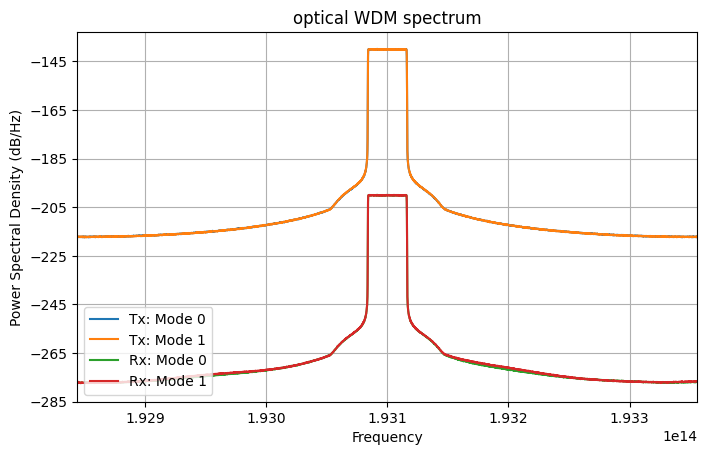

In [9]:
paramEDFA = parameters()
paramEDFA.G = paramFiber.alpha * paramFiber.L                                   # Ganho para compensar
paramEDFA.Fs = Fs
paramEDFA.NF = 9
paramEDFA.Fc = paramTx.Fc
sigCh = edfa(sigWDM_Tx, paramEDFA)                                              # modelo linear do EDFA

# # deteriorates the signal-to-noise ratio before the fiber
SNR = 13
sigAWGN = awgn(sigWDM_Tx, SNR, Fs, paramTx.Rs)

# simulate linear signal propagation
sigCh = linearFiberChannel(sigWDM_Tx, paramFiber)

# plot psd
fig,_ = plotPSD(sigWDM_Tx, Fs, paramFiber.Fc, label='Tx');
fig, ax = plotPSD(sigCh, Fs, paramFiber.Fc, fig=fig, label='Rx');
fig.set_figwidth(8)
ax.set_title('optical WDM spectrum');
print('P_sig[opt] = %.2f dBm'%(10*np.log10(signalPower(sigCh)/1e-3)))

Demodulating channel #0 , fc: 193.1000 THz, λ: 1552.5244 nm



ERROR:root:Simulation sampling frequency (Fs) not provided.


Local oscillator P: 10.00 dBm, lw: 500.00 kHz, FO: 150.00 MHz



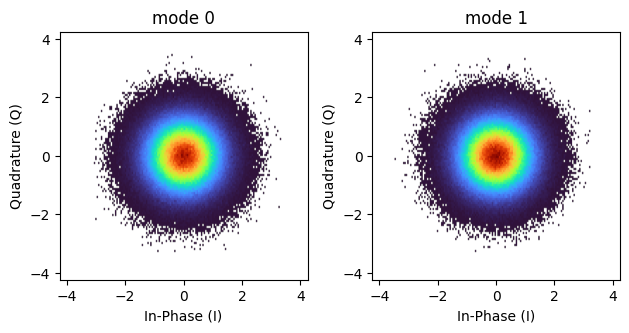

P_sig[opt] = -85.01 dBm


In [10]:
# parameters
chIndex = 0  # index of the channel to be demodulated

Fc = paramTx.Fc
Ts = 1/Fs
freqGrid = paramTx.wdmFreqGrid
π  = np.pi
t  = np.arange(0, len(sigCh))*Ts

print('Demodulating channel #%d , fc: %.4f THz, λ: %.4f nm\n'\
      %(chIndex, (Fc + freqGrid[chIndex])/1e12, c/(Fc + freqGrid[chIndex])/1e-9))

symbTx = symbTx_[:,:,chIndex]

# local oscillator (LO) parameters:
FO      = 150e6                 # frequency offset
Δf_lo   = freqGrid[chIndex]+FO  # downshift of the channel to be demodulated

# generate CW laser LO field
paramLO = parameters()
paramLO.P = 10              # power in dBm
paramLO.lw = 500e3          # laser linewidth
paramLO.RIN_var = 0
paramLO.Ns = len(sigCh)
paramLO.Fs = Fs

sigLO = basicLaserModel(paramLO)
sigLO = sigLO*np.exp(1j*2*π*Δf_lo*t) # add frequency offset

print('Local oscillator P: %.2f dBm, lw: %.2f kHz, FO: %.2f MHz\n'\
      %(paramLO.P, paramLO.lw/1e3, FO/1e6))

# polarization multiplexed coherent optical receiver

# photodiodes parameters
paramPD = parameters()
paramPD.B = paramTx.Rs
paramPD.Fs = Fs
paramPD.ideal = True

θsig = π/3 # polarization rotation angle
sigRx = pdmCoherentReceiver(sigCh, sigLO, θsig, paramPD)
# SNR = 25
# sigRx = awgn(sigRx, SNR, Fs, paramTx.Rs)

# plot received constellations
pconst(sigRx[0::paramTx.SpS], R=3);
print('P_sig[opt] = %.2f dBm'%(10*np.log10(signalPower(sigRx)/1e-3)))

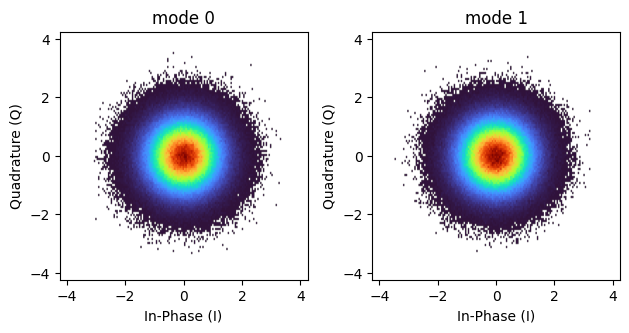

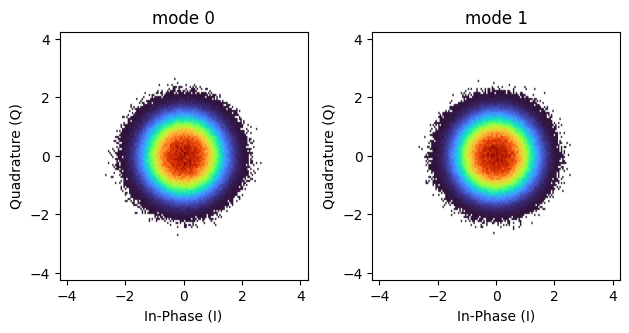

P_sig[opt] = -36.93 dBm


In [11]:
# Matched filtering
paramPulse              = parameters()
paramPulse.pulseType    = paramTx.pulseType
paramPulse.SpS          = paramTx.SpS
paramPulse.nFilterTaps  = paramTx.nFilterTaps
paramPulse.pulseRollOff = paramTx.pulseRollOff

pulse = pulseShape(paramPulse)
pulse = pnorm(pulse)

sigRx = firFilter(pulse, sigRx)

# plot constellations after matched filtering
pconst(sigRx[0::paramTx.SpS,:], R=3)

# CD compensation
paramEDC = parameters()
paramEDC.L = paramFiber.L
paramEDC.D = paramFiber.D
paramEDC.Fc = paramTx.Fc
paramEDC.Fs = Fs

sigRx = edc(sigRx, paramEDC)
pconst(sigRx[0::paramTx.SpS,:], R=3);
print('P_sig[opt] = %.2f dBm'%(10*np.log10(signalPower(sigRx)/1e-3)))

In [12]:
# decimate to one sample per symbol
paramDec = parameters()
paramDec.SpSin      = paramTx.SpS
paramDec.SpSout     = 1
sigRx = decimate(sigRx, paramDec)

x = (pnorm(sigRx))
print('P_sig[opt] = %.2f dBm'%(10*np.log10(signalPower(x)/1e-3)))

P_sig[opt] = 33.01 dBm


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

Tempo total = 3.27 s


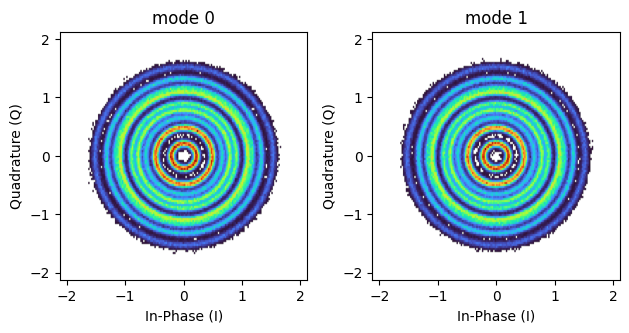

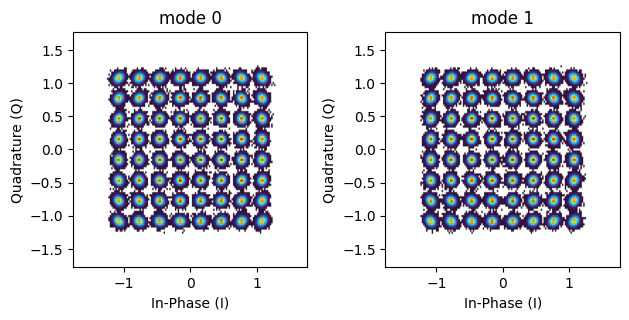

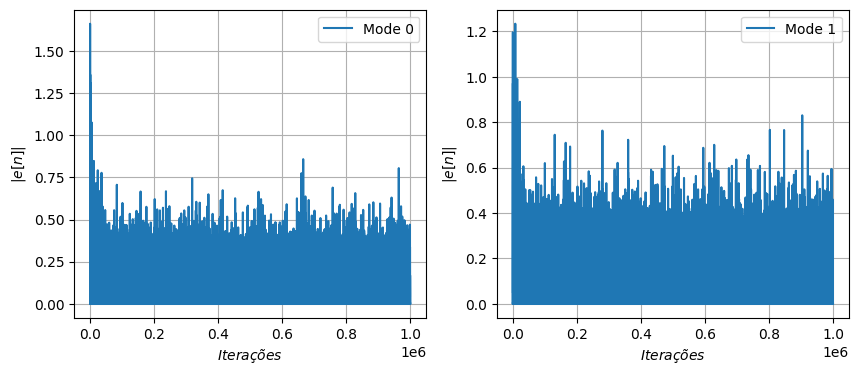

In [13]:
# parâmetros do equalizador
paramEq = parameters()
paramEq.nTaps = 15
paramEq.mu = [9e-1, 9e-2]
paramEq.M = paramTx.M
paramEq.constType = paramTx.constType
paramEq.N1   = 10000
paramEq.N2   = 25000
paramEq.alg = 'cma-to-rde'
paramEq.progBar = True

t_start3 = time.perf_counter()
y_EQ = mimoAdaptEq(x, paramEq)
t_end3 = time.perf_counter()
elapsed = t_end3 - t_start3
print(f"Tempo total = {elapsed:.2f} s")
discard = int(0.2 * y_EQ[0].shape[0])
pconst(y_EQ[0][discard:-discard,:], R=1.5);

paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = paramTx.M
paramCPR.N   = 75
paramCPR.B   = 64

y_CPR     = cpr(y_EQ[0], paramCPR)

discard = int(0.1 * y_CPR.shape[0])

#plot constellations after CPR
pconst(y_CPR[discard:-discard,:]);

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(np.abs(y_EQ[1][:, 0]), label='Mode 0')
axs[0].set_ylabel(r'$|e{[n]}|$')
axs[0].set_xlabel(r'$Iterações$')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(np.abs(y_EQ[1][:, 1]), label='Mode 1')
axs[1].set_ylabel(r'$|e{[n]}|$')
axs[1].set_xlabel(r'$Iterações$')
axs[1].legend()
axs[1].grid(True)

  0%|          | 0/488 [00:00<?, ?it/s]

Tempo total = 3.05 s


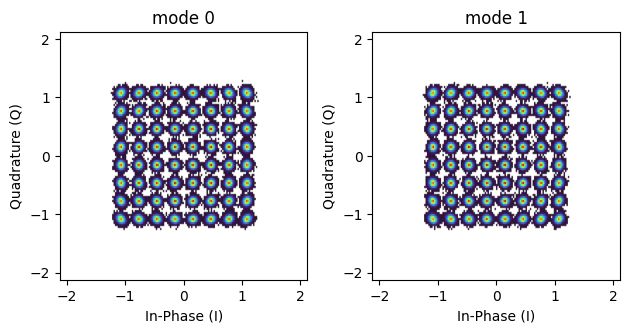

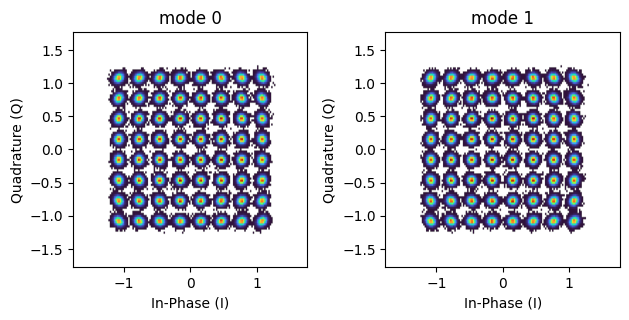

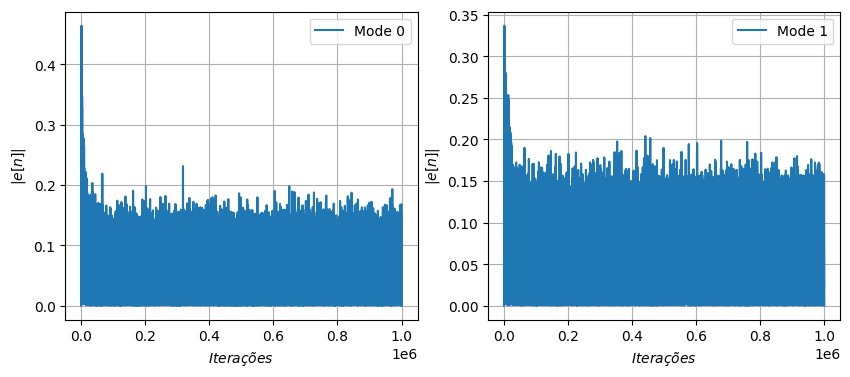

In [14]:
# Equalizador Adaptativo
paramEq.alg = 'dd-lms'
t_start2 = time.perf_counter()
y_LMS, e, _ = mimoAdaptEq(y_CPR, paramEq)
t_end2 = time.perf_counter()
elapsed = t_end2 - t_start2
print(f"Tempo total = {elapsed:.2f} s")
discard = int(0.1 * y_LMS.shape[0])
pconst(y_LMS[discard:-discard,:], R=1.5);

y_CPR_LMS = cpr(y_LMS, paramCPR)

discard = int(0.1 * y_CPR_LMS.shape[0])
pconst(y_CPR_LMS[discard:-discard,:]);

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(np.abs(e[:, 0]), label='Mode 0')
axs[0].set_ylabel(r'$|e{[n]}|$')
axs[0].set_xlabel(r'$Iterações$')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(np.abs(e[:, 1]), label='Mode 1')
axs[1].set_ylabel(r'$|e{[n]}|$')
axs[1].set_xlabel(r'$Iterações$')
axs[1].legend()
axs[1].grid(True)

In [15]:
def plotUtils(x, d, title):
    """
    Plote sinais com dois modos de polarização em conjunto
    com os símbolos do transmissor.

    Parameters
    ----------
    x : np.array
        Sinal de entrada com dois modos de polarização.

    d : np.array
        Símbolos do transmissor.

    title : string
        Titulo desejado.
    """

    if x.shape[1] != 2:
        raise ValueError('os sinais devem possuir dois modos de polarização')

    plt.plot(np.abs(x[:,0]), '.', color='black',  label = 'After CPR Mode 0')
    plt.plot(np.abs(x[:,1]), '.', color='purple', label = 'After CPR Mode 1')
    plt.plot(np.abs(d[:,0]), '.', color='orange', label = 'SymbTx')

    plt.title(title)
    plt.ylabel(r'$|y_{1,2}[k]|$')
    plt.xlabel(r'$k$')
    plt.ylim(0, 2)

    plt.legend(loc='upper center')
    plt.grid()

    plt.show()

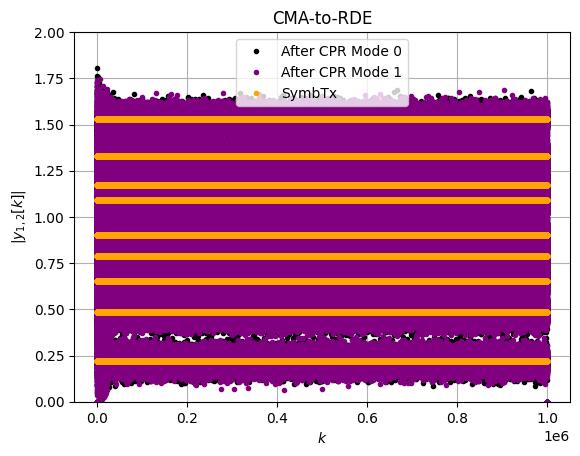

In [16]:
plotUtils(y_CPR, symbTx_, 'CMA-to-RDE')

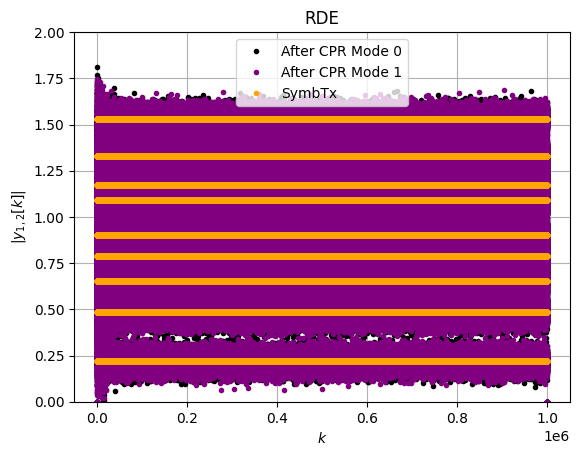

In [17]:
plotUtils(y_CPR_LMS, symbTx_, 'RDE')

In [18]:
d = pnorm(symbTx_)
ind = np.arange(discard, d.shape[0]-discard)
# Remove a 3ª dimensão
rx = y_CPR_LMS[ind,:]
tx = d[ind,:]

if rx.ndim == 3 and rx.shape[2] == 1:
    rx = rx[:, :, 0]
if tx.ndim == 3 and tx.shape[2] == 1:
    tx = tx[:, :, 0]

delay = finddelay(rx[:,1], tx[:,1])
print("Delay estimado (mode 0):", delay)

# Alinhar com symbolSync
tx_sync = symbolSync(rx, tx, SpS=1, mode='amp')

# Truncar sinais para comprimento comum
min_len = min(rx.shape[0], tx_sync.shape[0])
rx = rx[:min_len]
tx = tx_sync[:min_len]

delay = finddelay(rx[:,0], tx[:,0])
print("Delay estimado (mode 0):", delay)
rx = pnorm(rx)
tx = pnorm(tx)
BER, SER, SNR = fastBERcalc(rx, tx, paramTx.M, paramTx.constType)

print('      pol.X      pol.Y      ')
print(' SER: %.2e,  %.2e'%(SER[0], SER[1]))
print(' BER: %.2e,  %.2e'%(BER[0], BER[1]))
print(' SNR: %.2f dB,  %.2f dB'%(SNR[0], SNR[1]))

Delay estimado (mode 0): 0
Delay estimado (mode 0): 0
      pol.X      pol.Y      
 SER: 1.71e-04,  1.94e-04
 BER: 2.88e-05,  3.25e-05
 SNR: 25.94 dB,  25.94 dB


/home/marcos/PIBITI/venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/marcos/PIBITI/venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


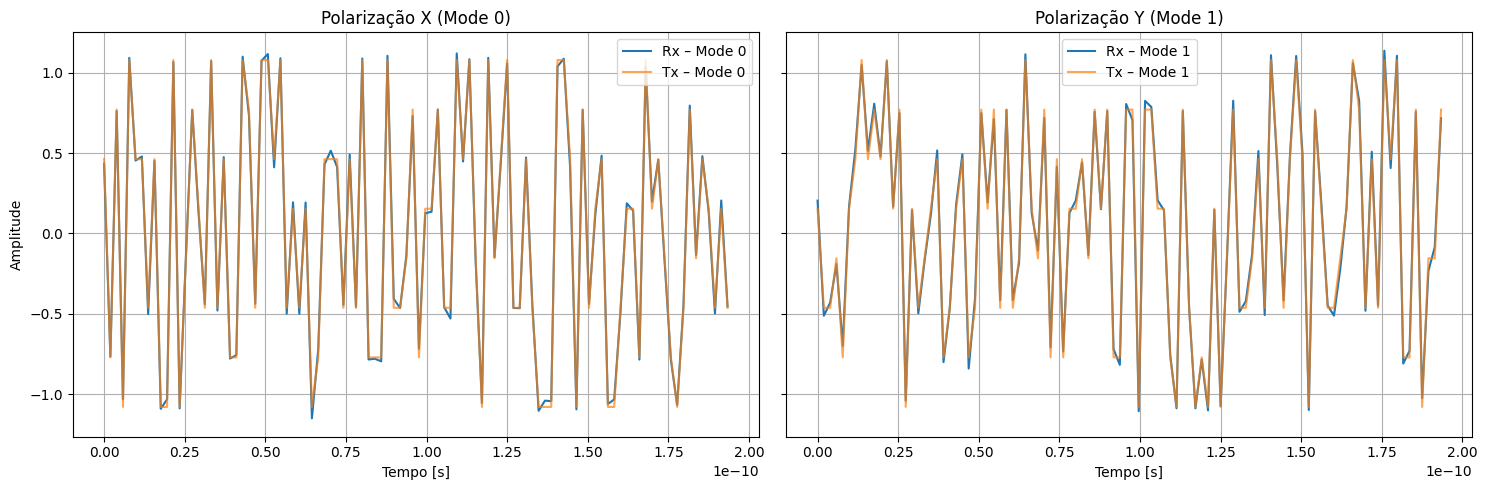

Tempo total = 416.12 s


In [19]:
t = np.arange(100) / Fs

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True);
# Modo X
axs[0].plot(t, rx[:100, 0], label="Rx – Mode 0")
axs[0].plot(t, tx[:100, 0], label="Tx – Mode 0", alpha=0.7)
axs[0].set_title("Polarização X (Mode 0)")
axs[0].set_xlabel("Tempo [s]")
axs[0].set_ylabel("Amplitude")
axs[0].legend();
axs[0].grid(True)

# Modo Y
axs[1].plot(t, rx[:100, 1], label="Rx – Mode 1")
axs[1].plot(t, tx[:100, 1], label="Tx – Mode 1", alpha=0.7)
axs[1].set_title("Polarização Y (Mode 1)")
axs[1].set_xlabel("Tempo [s]")
axs[1].legend();
axs[1].grid(True)

fig.tight_layout()
plt.show()
t_end = time.perf_counter()
elapsed = t_end - t_start
print(f"Tempo total = {elapsed:.2f} s")

### Resgistro das simulações em Numpy - Intel Xeon(R) W9-3495X
---
| Ordem de modulação (M) | Taxa de símbolos (Rs)| Amostras por símbolo (SpS) |  CD   | Perdas (dB) | EDFA  | AWGN (OSNR dB) | Rotação (PMD) | EQ - CMA → RDE (s) | DD-LMS (s) |  Tempo de simulação (s) | Num. bits |
| :--------------------: | :------------------: | :------------------------: | :---: | :--------:  | :---: | :------------: | :-----------: | :----------------: | :--------: | :---------------------: | :-------: |
|         64-QAM         |         32 (GBd)          |              16               | Sim |      Sim      |  Sim |        Sim       |     Sim     |   0.04  |      0.01      |  5.79  | 7e3 |
|         64-QAM         |         32 (GBd)          |              16               | Sim |      Sim      |  Sim |        Sim       |     Sim     |   0.06  |      0.02      | 8.51  | 2e4 |
|         64-QAM         |         32 (GBd)          |              16               | Sim |      Sim      |  Sim |        Sim       |     Sim     |   0.07  |      0.23      | 17.43  | 7e4 |
|         64-QAM         |         32 (GBd)          |              16               | Sim |      Sim      |  Sim |        Sim       |     Sim     |   0.27  |      0.24      | 62.53 | 3e5 |
|         64-QAM         |         32 (GBd)          |              16               | Sim |      Sim      |  Sim |        Sim       |     Sim     |   0.40  |      0.86      | 207.24 | 1e6 |
|         64-QAM         |         32 (GBd)          |              16               | Sim |      Sim      |  Sim |        Sim       |     Sim     |   2.27  |      4.29      | 1124.72 | 5e6 |
|         64-QAM         |         32 (GBd)          |              16               | Sim |      Sim      |  Sim |        Sim       |     Sim     |   5.57  |      9.39      | 2342.36 | 1e7 |

### Otimização dos Algoritmos por Vetorização em Blocos

Após a validação funcional dos algoritmos de equalização em uma implementação amostra-por-amostra, o foco do projeto se voltou para a otimização de performance. A abordagem sequencial, embora didática, possui um gargalo de desempenho significativo devido à sobrecarga de execução de um loop for em Python por centenas de milhares de iterações. Para superar essa limitação, foi implementada uma refatoração para vetorização em blocos, tanto para a versão em CPU (NumPy) quanto para a GPU (CuPy).

A principal mudança arquitetônica foi a eliminação do loop amostra-por-amostra em favor de um loop que itera sobre grandes blocos de dados. Dentro de cada iteração, as operações de filtragem e atualização de pesos foram transformadas em operações de matrizes de alta performance. A etapa chave para viabilizar essa vetorização foi a criação de uma função auxiliar, que utiliza a técnica de ```|stride_tricks|  |(numpy/cupy).lib.stride_tricks.as_strided|``` para pré-calcular todas as janelas de entrada do filtro para um bloco de uma só vez, de forma extremamente eficiente e sem a necessidade de cópias de memória.

Com as matrizes de janela de entrada ```|(xV e xH)|``` pré-calculadas, a operação de filtragem para um bloco inteiro foi reduzida a multiplicações de matrizes ```|(@ ou .dot)|```, e a atualização dos pesos foi calculada com base no gradiente médio do bloco. Esta abordagem delega os cálculos massivos para as rotinas de álgebra linear otimizadas do NumPy e do CuPy (em CUDA), minimizando drasticamente o controle sequencial da CPU. O ganho de performance com esta mudança foi gigantesco: simulações que antes duravam minutos passaram a ser executadas em menos de um segundo, tanto em NumPy quanto em CuPy.

### Conclusão

Neste projeto, comparou-se o desempenho de implementações de equalizadores adaptativos em CPU (NumPy) e GPU (CuPy), especificamente para o problema de mitigação de distorções em sistemas de comunicações ópticas coerentes. Os resultados desta pesquisa destacaram a enorme eficácia da aceleração por GPU para simulações computacionalmente intensivas. Além disso, foi observado que a arquitetura do algoritmo, seja ela amostra-por-amostra ou em blocos, tem um impacto fundamental tanto na performance computacional quanto na estabilidade da convergência.

Foi possível concluir que, para obter ganhos de performance significativos, a migração de uma lógica sequencial para uma arquitetura de processamento em blocos vetorizado é o passo crucial. Embora esta abordagem exija um ajuste mais cuidadoso de parâmetros como o passo de adaptação e o comprimento do filtro para garantir a estabilidade, ela se mostrou a única forma viável de extrair o potencial do processamento paralelo. Esta otimização resultou em ganhos de velocidade expressivos não apenas na GPU, mas também na implementação em CPU.

Observando o comportamento das plataformas quando submetidas a cargas de trabalho crescentes, vemos que a implementação em CPU com NumPy é adequada para a validação funcional e para simulações de pequena escala. Contudo, a análise de escalabilidade demonstrou que seu tempo de execução cresce de forma acentuada com o número de símbolos. Em contraste, a versão em GPU com CuPy, embora possua uma sobrecarga inicial, apresentou uma escalabilidade muito superior, tornando-se ordens de magnitude mais rápida para os grandes volumes de dados que uma análise estatística robusta (como o cálculo de BER) exige.

Portanto, para o ciclo de desenvolvimento de novas gerações de transceptores ópticos, a utilização de plataformas de simulação aceleradas por GPU em linguagens de alto nível como Python se mostra uma estratégia promissora. Ela permite a prototipagem e a otimização rápida de algoritmos de DSP complexos, reduzindo significativamente o tempo entre o conceito teórico e a validação. A capacidade de testar exaustivamente diferentes configurações de equalizadores em minutos, em vez de horas ou dias, acelera a inovação e pode levar ao desenvolvimento de ASICs mais eficientes e robustos para futuras redes de comunicação.

## Configurações dos parametros

### Configuração para Nbits = 7e3

`paramTx.nBits           = int(np.log2(paramTx.M)*7e3)                           # total number of bits per polarization`

`paramEq.nTaps = 3`

`paramEq.mu = [5e-1, 5e-2]`

`blockSize = 2**6`

`paramEq.N1   = 500`

`paramEq.N2   = 3000`

### Configuração para Nbits = 2e4

`paramTx.nBits           = int(np.log2(paramTx.M)*2e4)                           # total number of bits per polarization`

`paramEq.nTaps = 10`

`paramEq.mu = [7e-1, 7e-2]`

`blockSize = 2**9`

`paramEq.N1   = 4000`

`paramEq.N2   = 15000`

### Configuração para Nbits = 7e4

`paramTx.nBits           = int(np.log2(paramTx.M)*7e4)                           # total number of bits per polarization`

`paramEq.nTaps = 15`

`paramEq.mu = [7e-1, 7e-2]`

`blockSize = 2**10`

`paramEq.N1   = 7000`

`paramEq.N2   = 20000`

### Configuração para Nbits = 3e5

`paramTx.nBits           = int(np.log2(paramTx.M)*3e5)                           # total number of bits per polarization`

`paramEq.nTaps = 15`

`paramEq.mu = [9e-1, 9e-2]`

`blockSize = 2**11`

`paramEq.N1   = 10000`

`paramEq.N2   = 25000`

### Configuração para Nbits = 1e6

`paramTx.nBits           = int(np.log2(paramTx.M)*1e6)                           # total number of bits per polarization`

`paramEq.nTaps = 15`

`paramEq.mu = [9e-1, 9e-2]`

`blockSize = 2**11`

`paramEq.N1   = 15000`

`paramEq.N2   = 30000`

### Configuração para Nbits = 5e6

`paramTx.nBits           = int(np.log2(paramTx.M)*5e6)                           # total number of bits per polarization`

`paramEq.nTaps = 20`

`paramEq.mu = [9e-1, 9e-2]`

`blockSize = 2**12`

`paramEq.N1   = 20000`

`paramEq.N2   = 40000`

### Configuração para Nbits = 1e7

`paramTx.nBits           = int(np.log2(paramTx.M)*5e6)                           # total number of bits per polarization`

`paramEq.nTaps = 30`

`paramEq.mu = [10e-1, 10e-2]`

`blockSize = 2**12`

`paramEq.N1   = 50000`

`paramEq.N2   = 100000`